## Text Preprocessing & Lexical Exploration
Tokenisation, stop-word removal, word clouds and top bigrams per sentiment class.

In [1]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Free-text reviews used for NLP: 22448


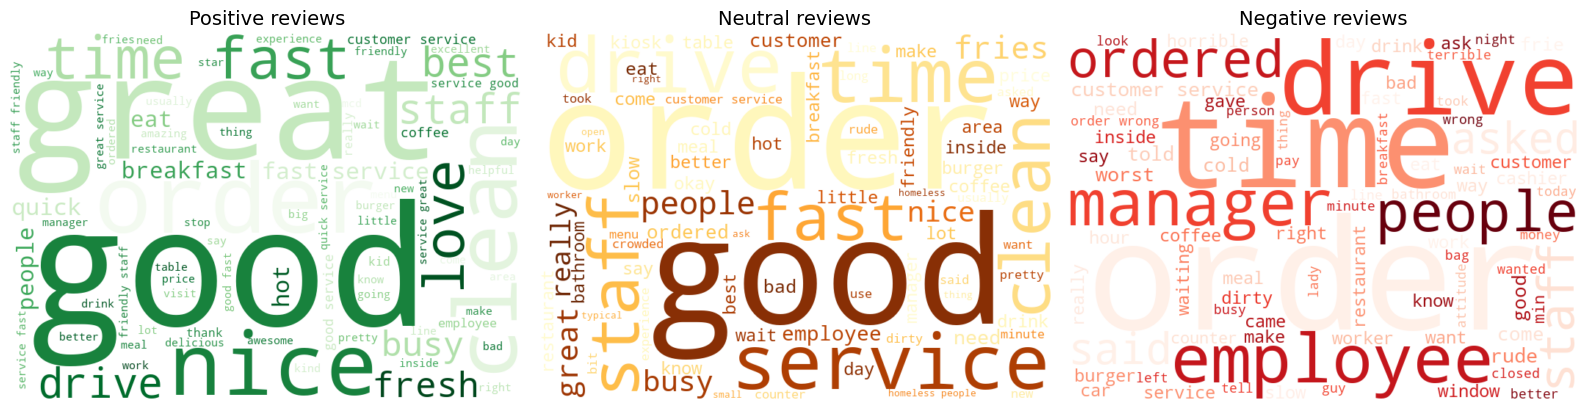

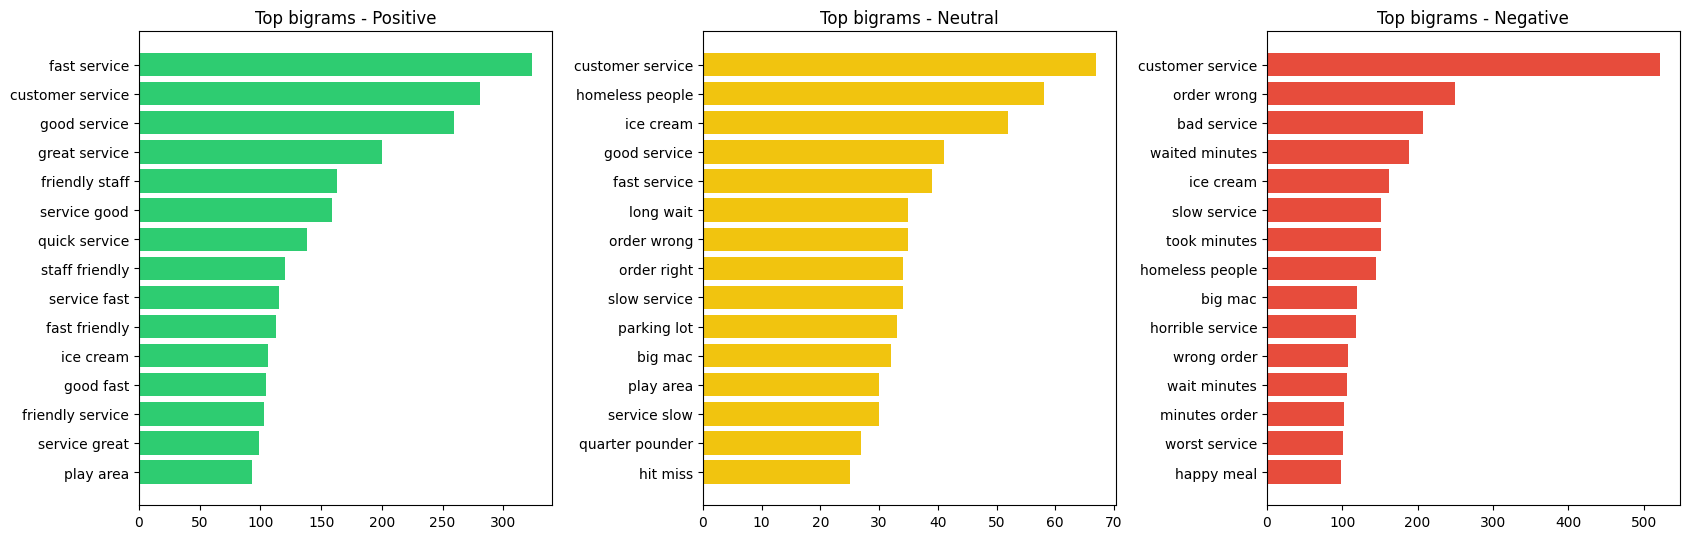

Saved word clouds and bigram charts


In [8]:
%matplotlib inline
import re
import pandas as pd
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

FIG = "Figures"
df = pd.read_csv("cleaned_reviews.csv")

# Only genuine free-text reviews are used for NLP/text modelling
text_df = df[~df["is_autotag"]].copy()
print("Free-text reviews used for NLP:", len(text_df))

CUSTOM_STOP = ENGLISH_STOP_WORDS.union({
    "mcdonalds", "mcdonald", "mc", "donalds", "location", "store", "just",
    "got", "went", "did", "didn", "don", "im", "ive", "food", "place"
})

def preprocess(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"[^a-z\s]", " ", t)          # keep letters only
    t = re.sub(r"\s+", " ", t).strip()
    tokens = [w for w in t.split() if w not in CUSTOM_STOP and len(w) > 2]
    return " ".join(tokens)

text_df["review_processed"] = text_df["review_clean"].apply(preprocess)
text_df = text_df[text_df["review_processed"].str.len() > 0]
text_df.to_csv("text_reviews_processed.csv", index=False)

# ---- Word clouds per sentiment -----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, sent, cmap in zip(axes, ["Positive", "Neutral", "Negative"],
                           ["Greens", "YlOrBr", "Reds"]):
    text = " ".join(text_df.loc[text_df["sentiment"] == sent, "review_processed"])
    wc = WordCloud(width=700, height=500, background_color="white",
                    colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{sent} reviews", fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{FIG}/05_wordclouds.png")


# ---- Top bigrams per sentiment -----------------------------------------
def top_ngrams(corpus, n=15, ngram_range=(2, 2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words="english", min_df=3)
    X = vec.fit_transform(corpus)
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    top = sorted(zip(vocab, freqs), key=lambda x: -x[1])[:n]
    return pd.DataFrame(top, columns=["ngram", "count"])

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, sent, color in zip(axes, ["Positive", "Neutral", "Negative"],
                            ["#2ecc71", "#f1c40f", "#e74c3c"]):
    corpus = text_df.loc[text_df["sentiment"] == sent, "review_processed"]
    top = top_ngrams(corpus)
    ax.barh(top["ngram"][::-1], top["count"][::-1], color=color)
    ax.set_title(f"Top bigrams - {sent}")
plt.tight_layout()
plt.savefig(f"{FIG}/06_top_bigrams.png")
plt.show()

print("Saved word clouds and bigram charts")
